In [1]:
import pandas as pd

train = pd.read_csv("train.csv", parse_dates=["Date"], low_memory=False)
store = pd.read_csv("store.csv")

In [2]:
train

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [3]:
store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [4]:
df = train.merge(store, on="Store", how="left")

İki fayl `Store` üzrə birləşdirildi ki, hər satış sətrində mağaza atributları da olsun.

In [5]:
print(df.shape)                      
print(df["StoreType"].isna().sum())  

(1017209, 18)
0


In [6]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [7]:
print(df["StateHoliday"].value_counts())
print(df["Open"].value_counts())
print((df["Sales"] == 0).sum())

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64
Open
1    844392
0    172817
Name: count, dtype: int64
172871


In [8]:
df[(df["Open"] == 1) & (df["Sales"] == 0)]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
86825,971,5,2015-05-15,0,0,1,0,0,1,c,a,1140.0,5.0,2011.0,1,14.0,2012.0,"Mar,Jun,Sept,Dec"
142278,674,4,2015-03-26,0,0,1,0,0,0,a,a,2640.0,12.0,2005.0,1,31.0,2013.0,"Feb,May,Aug,Nov"
196938,699,4,2015-02-05,0,0,1,1,0,0,a,a,180.0,NaN,NaN,1,5.0,2013.0,"Jan,Apr,Jul,Oct"
322053,708,3,2014-10-01,0,0,1,1,0,0,c,c,11470.0,10.0,2009.0,1,18.0,2014.0,"Jan,Apr,Jul,Oct"
330176,357,1,2014-09-22,0,0,1,0,0,0,a,a,2060.0,10.0,2008.0,0,NaN,NaN,NaN
340348,227,4,2014-09-11,0,0,1,0,0,0,a,a,2370.0,NaN,NaN,0,NaN,NaN,NaN
340860,835,4,2014-09-11,0,0,1,0,0,0,a,a,2890.0,12.0,2007.0,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
341795,835,3,2014-09-10,0,0,1,0,0,0,a,a,2890.0,12.0,2007.0,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
346232,548,5,2014-09-05,0,0,1,1,0,1,d,c,3760.0,2.0,2009.0,0,NaN,NaN,NaN
346734,28,4,2014-09-04,0,0,1,1,0,0,a,a,1200.0,10.0,2014.0,1,6.0,2015.0,"Mar,Jun,Sept,Dec"


In [9]:
df = df[(df["Open"] == 1) & (df["Sales"] > 0)].copy()
print(df.shape)

(844338, 18)


`Open = 0` olan sətirlər və `Open = 1`, lakin `Sales = 0` olan şübhəli sətirlər çıxarıldı. Bağlı mağazanın sıfır satışı tələbin olmamasını yox, mağazanın işləməməsini göstərir və gündəlik ortanı süni şəkildə aşağı salardı.

In [10]:
df["StateHoliday"] = df["StateHoliday"].astype(str)
print(df["StateHoliday"].value_counts())

StateHoliday
0    843428
a       694
b       145
c        71
Name: count, dtype: int64


In [11]:
df = df.drop(columns=["CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
                      "Promo2SinceWeek", "Promo2SinceYear", "PromoInterval", "Customers"])

`StateHoliday` sütunu tək tipə (`str`) gətirildi, çünki həm rəqəm `0`, həm mətn `"0"` qarışıq idi. `Customers` sütunu proqnoz zamanı gələcək üçün məlum olmadığından (leakage riski), tələb olunmayan `CompetitionOpenSince*` və `Promo2Since*` sütunları isə istifadə edilməyəcəyi üçün çıxarıldı.

In [12]:
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())
print("CompetitionDistance boş:", df["CompetitionDistance"].isna().sum())

CompetitionDistance boş: 0


Boş `CompetitionDistance` dəyərləri median ilə dolduruldu. Paylanma sağa çəkilmiş olduğu üçün median, orta qiymətə nisbətən ekstremal dəyərlərdən daha az təsirlənir.

In [13]:
import matplotlib.pyplot as plt

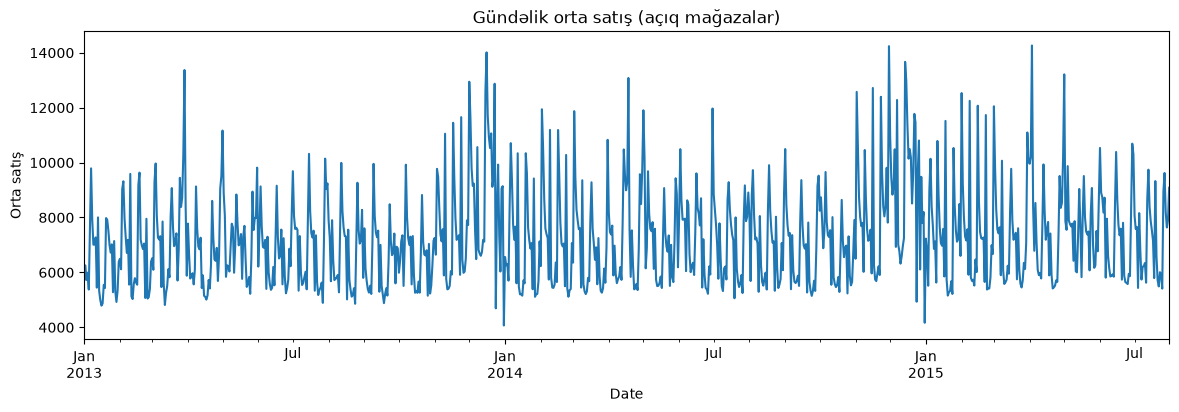

In [14]:
daily = df.groupby("Date")["Sales"].mean()

plt.figure(figsize=(14, 4))
daily.plot()
plt.title("Gündəlik orta satış (açıq mağazalar)")
plt.ylabel("Orta satış")
plt.show()

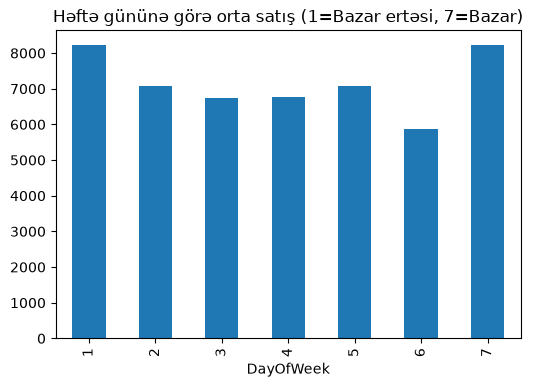

In [15]:
df.groupby("DayOfWeek")["Sales"].mean().plot(kind="bar", figsize=(6, 4))
plt.title("Həftə gününə görə orta satış (1=Bazar ertəsi, 7=Bazar)")
plt.show()

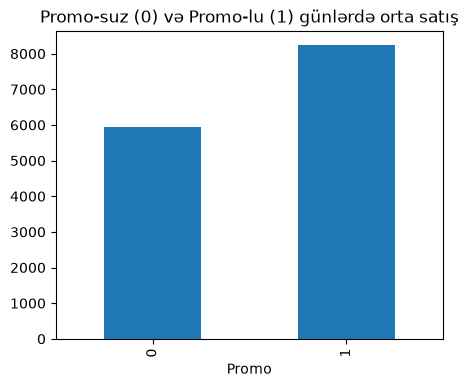

In [17]:
df.groupby("Promo")["Sales"].mean().plot(kind="bar", figsize=(5, 4))
plt.title("Promo-suz (0) və Promo-lu (1) günlərdə orta satış")
plt.show()

Bu qrafiklər seriyanın strukturunu (trend, həftəlik və illik mövsümilik) və `Promo`, bayram, mağaza tipi kimi xarici amillərin satışla əlaqəsini yoxlamaq üçün çəkildi. Nəticələr seriya qurulması qərarına əsas olacaq.

In [18]:
print(df.groupby("StateHoliday")["Sales"].mean().round(0))
print(df.groupby("StoreType")["Sales"].mean().round(0))

StateHoliday
0    6954.0
a    8487.0
b    9888.0
c    9744.0
Name: Sales, dtype: float64
StoreType
a     6926.0
b    10233.0
c     6933.0
d     6822.0
Name: Sales, dtype: float64


In [38]:
print(df.groupby("Assortment")["Sales"].mean().round(0))
print(df.groupby("Assortment")["Store"].nunique())

Assortment
a    6622.0
b    8643.0
c    7301.0
Name: Sales, dtype: float64
Assortment
a    593
b      9
c    513
Name: Store, dtype: int64


In [40]:
daily = df.groupby("Date").agg(
    Sales=("Sales", "mean"),
    Promo=("Promo", "mean"),
    Promo2=("Promo2", "mean"),
    SchoolHoliday=("SchoolHoliday", "mean"),
    StateHoliday=("StateHoliday", lambda s: (s != "0").any()),
    TypeB_share=("StoreType", lambda s: (s == "b").mean()),
    AssortC_share=("Assortment", lambda s: (s == "c").mean()),
    CompDist=("CompetitionDistance", "median"),
    OpenStores=("Store", "count"),
).reset_index()

daily["StateHoliday"] = daily["StateHoliday"].astype(int)
daily

,Date,Sales,Promo,Promo2,SchoolHoliday,StateHoliday,TypeB_share,AssortC_share,CompDist,OpenStores
0,2013-01-01,5719.705882,0.0,0.294118,1.000000,1,0.941176,0.117647,1180.0,17
1,2013-01-02,6255.471647,0.0,0.513051,1.000000,0,0.014401,0.459046,2320.0,1111
2,2013-01-03,5723.913436,0.0,0.513075,0.932372,0,0.014427,0.458070,2330.0,1109
3,2013-01-04,5991.835740,0.0,0.512635,0.932310,0,0.013538,0.458484,2330.0,1108
4,2013-01-05,5376.326107,0.0,0.513098,0.100271,0,0.013550,0.457995,2330.0,1107
...,...,...,...,...,...,...,...,...,...,...
937,2015-07-27,9620.208446,1.0,0.512129,0.772686,0,0.015274,0.460916,2320.0,1113
938,2015-07-28,8189.643306,1.0,0.512129,0.772686,0,0.015274,0.460916,2320.0,1113
939,2015-07-29,7636.982929,1.0,0.512129,0.772686,0,0.015274,0.460916,2320.0,1113
940,2015-07-30,7905.529200,1.0,0.512129,0.838275,0,0.015274,0.460916,2320.0,1113


Prophet yalnız bir zaman seriyası qəbul etdiyi üçün mağaza-gün sətirləri gündəlik səviyyəyə çevrildi. Hədəf `Sales` həmin gün açıq olan mağazaların orta satışıdır (Variant B). `Promo`, `SchoolHoliday`, `TypeB_share` kimi mağaza səviyyəli sütunlar isə gündəlik pay kimi ifadə olundu, çünki bir gün üçün bir dəyər lazımdır.

In [42]:
test_days = 48
train = daily.iloc[:-test_days].copy()
test = daily.iloc[-test_days:].copy()

print(train["Date"].min(), train["Date"].max(), len(train))
print(test["Date"].min(), test["Date"].max(), len(test))

2013-01-01 00:00:00 2015-06-13 00:00:00 894
2015-06-14 00:00:00 2015-07-31 00:00:00 48


Data zamana görə bölündü: son 48 gün test, əvvəlki hissə train kimi ayrıldı. Təsadüfi bölgü istifadə edilmədi, çünki bu, modelin gələcək günlər haqqında məlumat görməsinə (leakage) səbəb olardı. Bütün modellər eyni train və eyni test dövründə qiymətləndiriləcək.

In [43]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [44]:
from prophet import Prophet

# Prophet yalnız ds (tarix) və y (hədəf) istəyir
train_p = train.rename(columns={"Date": "ds", "Sales": "y"})[["ds", "y"]]
test_p = test.rename(columns={"Date": "ds", "Sales": "y"})[["ds", "y"]]

m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.add_country_holidays(country_name="DE")   # Almaniya bayramları
m.fit(train_p)

forecast = m.predict(test_p[["ds"]])
test["prophet_pred"] = forecast["yhat"].values
print(test[["Date", "Sales", "prophet_pred"]].head())

10:05:57 - cmdstanpy - INFO - Chain [1] start processing
10:05:58 - cmdstanpy - INFO - Chain [1] done processing


          Date         Sales  prophet_pred
894 2015-06-14   8422.906250   8936.796462
895 2015-06-15  10386.086176   8531.286975
896 2015-06-16   8650.580790   7375.806827
897 2015-06-17   7736.515260   6994.894224
898 2015-06-18   7353.104129   7071.036197


Prophet baseline modeli yalnız `ds` (tarix) və `y` (satış) sütunları ilə train üzərində öyrədildi. Model trend, həftəlik və illik mövsümilik və Almaniya bayramlarını öyrənir, `Promo` kimi xarici amilləri görmür. Bu model hybrid və XGBoost üçün müqayisə baza xəttidir.

In [45]:
import numpy as np

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mask = y_true != 0                      # Sales = 0 olanları çıxar
    rmspe = np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2)) * 100
    return {"MAE": mae, "MAPE %": mape, "RMSPE %": rmspe}

results = {}
results["Prophet"] = metrics(test["Sales"], test["prophet_pred"])
print(results["Prophet"])

{'MAE': np.float64(1001.7850844544827), 'MAPE %': np.float64(14.05475996268606), 'RMSPE %': np.float64(16.889539218172107)}


Bütün modellər eyni `metrics` funksiyası ilə qiymətləndirilir ki, müqayisə ədalətli olsun. `MAE` mütləq xətanı, `MAPE` nisbi xətanı, `RMSPE` isə böyük nisbi səhvləri daha çox cəzalandıran Kaggle metrikasını ölçür. `RMSPE`-də `Sales = 0` sətirləri sıfıra bölmə olmasın deyə çıxarılır.

In [46]:
train_fc = m.predict(train_p[["ds"]])
train["prophet_pred"] = train_fc["yhat"].values
train["residual"] = train["Sales"] - train["prophet_pred"]

test["residual"] = test["Sales"] - test["prophet_pred"]   # yalnız müqayisə üçün
print(train["residual"].describe())
print(train.groupby("Promo")["residual"].mean().round(0))

count     894.000000
mean        0.723980
std      1341.066355
min     -3880.355012
25%      -996.996603
50%        23.699379
75%       828.138878
max      4235.405105
Name: residual, dtype: float64
Promo
0.0    -623.0
1.0    1017.0
Name: residual, dtype: float64


`residual` Prophet-in izah edə bilmədiyi hissəni göstərir (real satış − Prophet proqnozu). Hybrid modeldə XGBoost-un hədəfi məhz bu sütundur. Test qalığı yalnız müqayisə üçün hesablandı və öyrənməyə daxil edilmədi.

In [47]:
print("Train MAE:", train["residual"].abs().mean())
print("Test MAE :", test["residual"].abs().mean())

Train MAE: 1068.0244941314236
Test MAE : 1001.7850844544827


Prophet-in train və test üzrə MAE dəyərləri müqayisə edildi. Məqsəd train qalıqlarının (in-sample) test qalıqlarından nə qədər fərqləndiyini yoxlamaq idi, çünki XGBoost məhz train qalıqları üzərində öyrənir.

In [51]:
from xgboost import XGBRegressor

features = ["Promo", "Promo2", "SchoolHoliday", "StateHoliday",
            "TypeB_share", "AssortC_share", "CompDist", "OpenStores"]

for d in (train, test):
    d["dow"] = d["Date"].dt.dayofweek
    d["month"] = d["Date"].dt.month
features += ["dow", "month"]

xgb_res = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
xgb_res.fit(train[features], train["residual"])      # hədəf: qalıq

test["res_pred"] = xgb_res.predict(test[features])
test["hybrid_pred"] = test["prophet_pred"] + test["res_pred"]

results["Hybrid"] = metrics(test["Sales"], test["hybrid_pred"])
print(results["Prophet"])
print(results["Hybrid"])

{'MAE': np.float64(1001.7850844544827), 'MAPE %': np.float64(14.05475996268606), 'RMSPE %': np.float64(16.889539218172107)}
{'MAE': np.float64(526.2532388083006), 'MAPE %': np.float64(7.074254623436484), 'RMSPE %': np.float64(8.2435116803612)}


XGBoost `residual` hədəfi üzrə `Promo`, `StateHoliday`, `SchoolHoliday`, mağaza payları, `dow` və `month` xüsusiyyətləri ilə öyrədildi. Yekun hybrid proqnoz Prophet proqnozu ilə XGBoost-un qalıq düzəlişinin cəmidir. `Sales` və `Date` xüsusiyyət siyahısına daxil edilmədi ki, leakage olmasın.

In [52]:
for d in (train, test):
    d["dayofyear"] = d["Date"].dt.dayofyear
    d["weekofyear"] = d["Date"].dt.isocalendar().week.astype(int)
    d["t"] = (d["Date"] - train["Date"].min()).dt.days   

features_e2e = features + ["dayofyear", "weekofyear", "t"]

xgb_e2e = XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42)
xgb_e2e.fit(train[features_e2e], train["Sales"])        

test["xgb_pred"] = xgb_e2e.predict(test[features_e2e])
results["XGBoost"] = metrics(test["Sales"], test["xgb_pred"])

for k in ["Prophet", "XGBoost", "Hybrid"]:
    print(k, results[k])

Prophet {'MAE': np.float64(1001.7850844544827), 'MAPE %': np.float64(14.05475996268606), 'RMSPE %': np.float64(16.889539218172107)}
XGBoost {'MAE': np.float64(514.4940433796042), 'MAPE %': np.float64(7.079122170066034), 'RMSPE %': np.float64(8.209648818037566)}
Hybrid {'MAE': np.float64(526.2532388083006), 'MAPE %': np.float64(7.074254623436484), 'RMSPE %': np.float64(8.2435116803612)}


Prophet-siz model qurmaq üçün XGBoost birbaşa `Sales` hədəfi üzrə öyrədildi. Zaman strukturunu özü öyrənməsi üçün `dayofyear`, `weekofyear` və trend indeksi `t` əlavə edildi. Hyperparametrlər hybrid ilə eyni saxlanıldı ki, fərq yalnız yanaşmadan gəlsin.

             MAE  MAPE %  RMSPE %
Prophet  1001.79   14.05    16.89
Hybrid    526.25    7.07     8.24
XGBoost   514.49    7.08     8.21


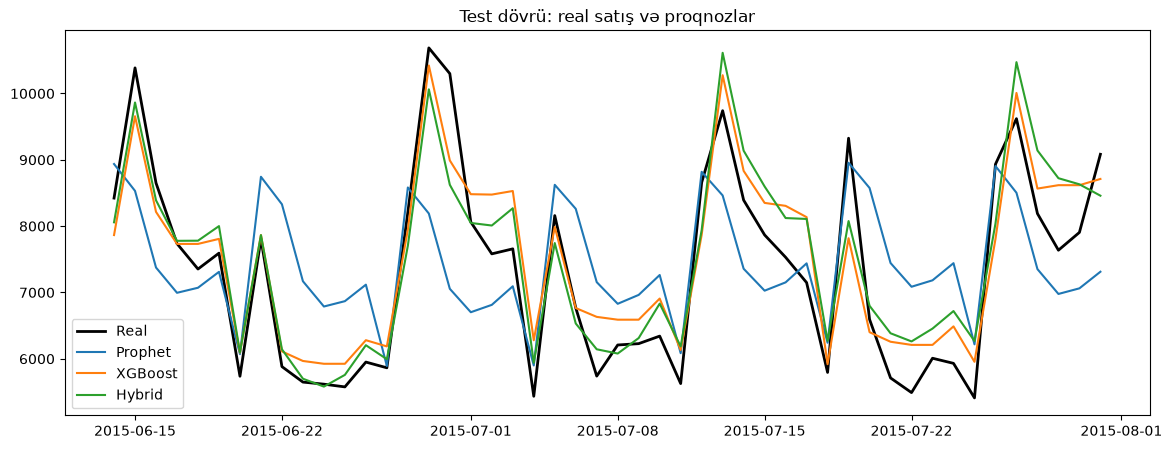

In [64]:
comp = pd.DataFrame(results).T.round(2)
print(comp)

plt.figure(figsize=(14, 5))
plt.plot(test["Date"], test["Sales"], label="Real", color="black", linewidth=2)
plt.plot(test["Date"], test["prophet_pred"], label="Prophet")
plt.plot(test["Date"], test["xgb_pred"], label="XGBoost")
plt.plot(test["Date"], test["hybrid_pred"], label="Hybrid")
plt.legend()
plt.title("Test dövrü: real satış və proqnozlar")
plt.show()

Prophet, end-to-end XGBoost və hybrid modelləri eyni test dövründə `MAE`, `MAPE` və `RMSPE` ilə müqayisə edildi. Qrafik real satışı və üç proqnozu birlikdə göstərir.

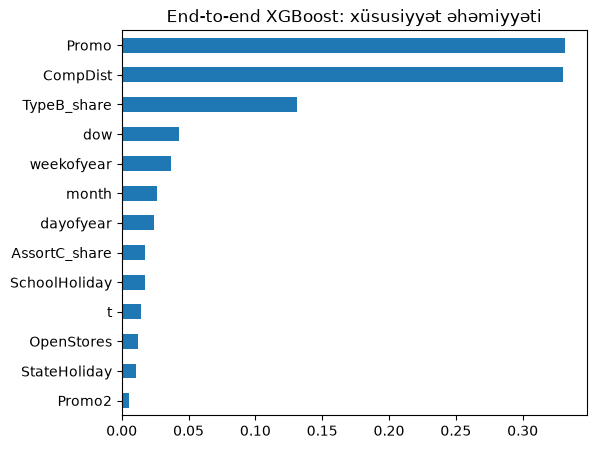

In [62]:
imp = pd.Series(xgb_e2e.feature_importances_, index=features_e2e).sort_values()
imp.plot(kind="barh", figsize=(6, 5))
plt.title("End-to-end XGBoost: xüsusiyyət əhəmiyyəti")
plt.show()

End-to-end XGBoost-un `feature_importances_` göstəricisi ilə hansı xüsusiyyətlərin proqnoza daha çox təsir etdiyi sıralandı. Gündəlik ortaya sıxılmış `CompDist` və `TypeB_share` kimi sütunlar real rəqib və ya tip təsirindən çox, açıq mağaza tərkibini əks etdirə bilər, ona görə şərh ehtiyatla aparılmalıdır.